# QTCAD M10 Quantum Transport — Result Analysis

이 노트북은 아래 QTCAD 예제 폴더의 결과를 실제로 불러와 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M10. Quantum transport\Reference`

분석 대상:
- `fdsoi_negf.py` (FD-SOI 트랜지스터 NEGF-Poisson 시뮬레이션 스크립트)
- `fdsoi_negf_run.log`, `fdsoi_negf_run2.log`, `fdsoi_negf_run3.log` (실행 로그, 3회 시도)
- `output/band_0.png`, `output/ldos_0.png`, `output/spectral_current_0.png` (Off-state 결과 그림)
- `poisson_negf_master.py` (Poisson + Schrödinger + NEGF + Master equation 결합 스크립트)
- `output/fdsoi_poisson_negf_master_current.png`, `output/fdsoi_poisson_negf_master_ldos.png`, `output/fdsoi_poisson_negf_master_ldos_zoom.png`
- `output/PNEGF_current_scale.txt`, `output/PNEGF_current_featureless.png`, `output/PNEGF_Current_scale.png`
- `output/PNEGF_CSD_scale.txt`, `output/PNEGF_Charge_diagram.png`

주요 산출물:
1. NEGF-Poisson 자기 일관성 수렴 이력 (3회 실행 로그 비교, 실제 성공한 실행 식별)
2. Off-state conduction band edge / LDOS / spectral current 해석
3. 3-bias-point 소자 설계(Off / sequential tunneling / On) 대비 실제로 저장된 결과 점검
4. 근평형(near-equilibrium) NEGF LDOS로부터 양자점 속박상태 확인
5. Master-equation 게이트 스윕 전류에서 Coulomb peak 위치 재검출 및 스크립트 출력값과 교차검증
6. Coulomb peak 간격(주기성) 분석
7. Charge-stability diagram(CSD) raw 데이터 재구성 및 Coulomb diamond 경계 추정
8. NEGF/Master-equation 기반 수송 해석과 Poisson 전용 정전용량 해석(M06)의 개념적 차이 정리

> 원본 QTCAD 파일은 수정하지 않습니다. 이 노트북은 `output/` 폴더에 이미 저장된 결과만 읽습니다.


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import Image, display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M10. Quantum transport\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "output"

# fdsoi_negf.py 관련 파일
FILE_NEGF_SCRIPT = BASE_DIR / "fdsoi_negf.py"
LOG_FILES = {
    "run1": BASE_DIR / "fdsoi_negf_run.log",
    "run2": BASE_DIR / "fdsoi_negf_run2.log",
    "run3": BASE_DIR / "fdsoi_negf_run3.log",
}
IMG_BAND_0 = OUTPUT_DIR / "band_0.png"
IMG_LDOS_0 = OUTPUT_DIR / "ldos_0.png"
IMG_SPECTRAL_0 = OUTPUT_DIR / "spectral_current_0.png"

# poisson_negf_master.py 관련 파일
FILE_MASTER_SCRIPT = BASE_DIR / "poisson_negf_master.py"
IMG_PNEGF_CURRENT = OUTPUT_DIR / "fdsoi_poisson_negf_master_current.png"
IMG_PNEGF_LDOS = OUTPUT_DIR / "fdsoi_poisson_negf_master_ldos.png"
IMG_PNEGF_LDOS_ZOOM = OUTPUT_DIR / "fdsoi_poisson_negf_master_ldos_zoom.png"
FILE_CURRENT_SCALE_TXT = OUTPUT_DIR / "PNEGF_current_scale.txt"
IMG_CURRENT_FEATURELESS = OUTPUT_DIR / "PNEGF_current_featureless.png"
IMG_CURRENT_SCALE = OUTPUT_DIR / "PNEGF_Current_scale.png"
FILE_CSD_SCALE_TXT = OUTPUT_DIR / "PNEGF_CSD_scale.txt"
IMG_CHARGE_DIAGRAM = OUTPUT_DIR / "PNEGF_Charge_diagram.png"

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"

print("\n[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M10. Quantum transport\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M10. Quantum transport\Reference\output

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "fdsoi_negf.py": FILE_NEGF_SCRIPT,
    "fdsoi_negf_run.log": LOG_FILES["run1"],
    "fdsoi_negf_run2.log": LOG_FILES["run2"],
    "fdsoi_negf_run3.log": LOG_FILES["run3"],
    "band_0.png": IMG_BAND_0,
    "ldos_0.png": IMG_LDOS_0,
    "spectral_current_0.png": IMG_SPECTRAL_0,
    "poisson_negf_master.py": FILE_MASTER_SCRIPT,
    "fdsoi_poisson_negf_master_current.png": IMG_PNEGF_CURRENT,
    "fdsoi_poisson_negf_master_ldos.png": IMG_PNEGF_LDOS,
    "fdsoi_poisson_negf_master_ldos_zoom.png": IMG_PNEGF_LDOS_ZOOM,
    "PNEGF_current_scale.txt": FILE_CURRENT_SCALE_TXT,
    "PNEGF_current_featureless.png": IMG_CURRENT_FEATURELESS,
    "PNEGF_Current_scale.png": IMG_CURRENT_SCALE,
    "PNEGF_CSD_scale.txt": FILE_CSD_SCALE_TXT,
    "PNEGF_Charge_diagram.png": IMG_CHARGE_DIAGRAM,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan,
        "modified": pd.Timestamp(path.stat().st_mtime, unit="s") if path.exists() else pd.NaT,
    })

inventory_df = pd.DataFrame(rows)
inventory_df.to_csv(EXPORT_DIR / "cell02_inventory_df.csv", index=False)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")

# 참고: band_1/2, ldos_1/2, spectral_current_1/2 (sequential tunneling, on state)는
# fdsoi_negf.py가 설계상 생성해야 하지만 output 폴더에 존재하는지 별도로 확인한다.
other_regime_files = [
    OUTPUT_DIR / "band_1.png", OUTPUT_DIR / "band_2.png",
    OUTPUT_DIR / "ldos_1.png", OUTPUT_DIR / "ldos_2.png",
    OUTPUT_DIR / "spectral_current_1.png", OUTPUT_DIR / "spectral_current_2.png",
]
found_other = [p.name for p in other_regime_files if p.exists()]
print("Sequential-tunneling / On-state 결과 파일 존재 여부:", found_other if found_other else "없음 (규제 0만 저장됨)")


,file,exists,size_KB,modified
0,fdsoi_negf.py,True,4.149414,2026-09-14 14:13:44.000000000
1,fdsoi_negf_run.log,True,9.096680,2026-09-29 05:14:53.817879915
2,fdsoi_negf_run2.log,True,8.761719,2026-09-29 06:09:59.031243324
3,fdsoi_negf_run3.log,True,10.740234,2026-09-29 07:22:29.359198332
4,band_0.png,True,30.146484,2026-09-29 07:33:50.241567850
5,ldos_0.png,True,52.967773,2026-09-29 07:35:19.155559301
6,spectral_current_0.png,True,28.153320,2026-09-29 07:35:28.560951710
7,poisson_negf_master.py,True,10.654297,2026-09-30 01:21:40.404540062
8,fdsoi_poisson_negf_master_current.png,True,34.538086,2026-09-30 01:39:55.963017702
9,fdsoi_poisson_negf_master_ldos.png,True,55.299805,2026-09-30 01:40:35.715029240



[OK] 분석 대상 파일이 모두 존재합니다.
Sequential-tunneling / On-state 결과 파일 존재 여부: 없음 (규제 0만 저장됨)


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Transport 4: NEGF-Poisson simulations of an FD-SOI FET with a QD
  https://docs.nanoacademic.com/qtcad/tutorials/transport/fdsoi_negf/
- **QTCAD 공식 튜토리얼** — Transport 5: Poisson-NEGF-Master-equation simulations of an FD-SOI FET
  https://docs.nanoacademic.com/qtcad/tutorials/transport/poisson_negf_master/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `fdsoi_negf.py`, `poisson_negf_master.py` (M10/Reference)
---


## 0. 소자 스케매틱 + 핵심 물리 공식

`fdsoi_negf.geo` 치수(소스/드레인 20nm, barrier 4nm x2, plunger 15nm, buffer 10nm x4,
Si 두께 3nm, top oxide 2nm, bottom oxide 15nm)를 그대로 재구성합니다. M03/M06의 FD-SOI
이중점과 달리 **단일** 양자점 + **quantum lead 경계**(NEGF 전용, source/drain을 열린
계(open system)의 저장소로 취급)를 사용합니다.

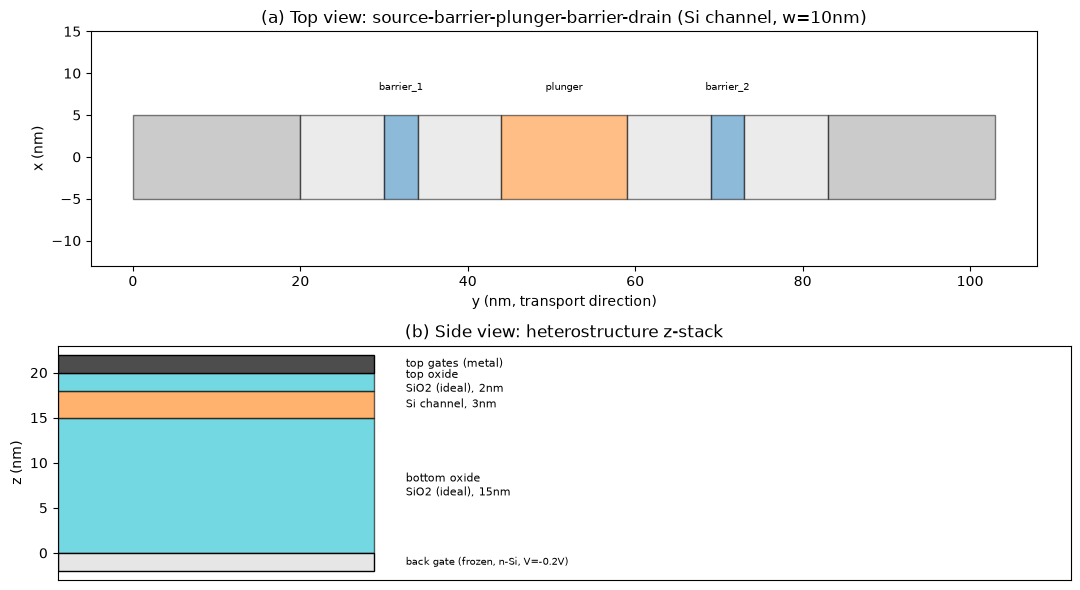

,parameter,intent
0,"source/drain quantum lead bnd (NEGF), Vds=0.05V",일반 ohmic 경계 대신 NEGF 전용 'quantum lead' 경계로 sour...
1,"barrier_gate: 0.7/0.7/1.7V, plunger_gate: 0.7/...","Off-state(낮은 전압), sequential-tunneling(살짝 디튜닝)..."
2,Si 두께 3nm (fdsoi_negf.geo t_si),강한 양자 구속으로 단일 서브밴드에 가까운 전도 — NEGF 투과 스펙트럼 해석을 ...


In [3]:
# [실험] 소자 스케매틱 (fdsoi_negf.geo 치수 그대로)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M10. Quantum transport\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

segs_y = [("source\nSi n+ (quantum lead)", 20, "0.6"), ("buffer\nSi", 10, "0.85"),
         ("barrier_1\nSi", 4, "tab:blue"), ("buffer\nSi", 10, "0.85"),
         ("plunger\nSi", 15, "tab:orange"), ("buffer\nSi", 10, "0.85"),
         ("barrier_2\nSi", 4, "tab:blue"), ("buffer\nSi", 10, "0.85"),
         ("drain\nSi n+ (quantum lead)", 20, "0.6")]
w_si = 10.0

fig, axs = plt.subplots(2, 1, figsize=(11, 6))
ax = axs[0]
y0 = 0
for name, L, color in segs_y:
    ax.add_patch(mpatches.Rectangle((y0, -w_si/2), L, w_si, fc=color, alpha=0.5, ec="k"))
    if "gate" in name.lower() or name.split("\n")[0] in ("barrier_1", "plunger", "barrier_2"):
        ax.text(y0+L/2, w_si/2+3, name.split("\n")[0], ha="center", fontsize=7)
    y0 += L
ax.set_xlim(-5, y0+5); ax.set_ylim(-w_si/2-8, w_si/2+10)
ax.set_xlabel("y (nm, transport direction)"); ax.set_ylabel("x (nm)")
ax.set_title("(a) Top view: source-barrier-plunger-barrier-drain (Si channel, w=10nm)")
ax.set_aspect("equal")

ax2 = axs[1]
z_layers = [("bottom oxide\nSiO2 (ideal), 15nm", 15, "tab:cyan"),
           ("Si channel, 3nm", 3, "tab:orange"),
           ("top oxide\nSiO2 (ideal), 2nm", 2, "tab:cyan")]
z0 = 0
for name, thick, color in z_layers:
    ax2.add_patch(mpatches.Rectangle((0, z0), 1, thick, fc=color, alpha=0.6, ec="k"))
    ax2.text(1.1, z0+thick/2, name, va="center", fontsize=8)
    z0 += thick
ax2.add_patch(mpatches.Rectangle((0, z0), 1, 2, fc="0.3", ec="k"))
ax2.text(1.1, z0+1, "top gates (metal)", va="center", fontsize=8)
ax2.add_patch(mpatches.Rectangle((0, -2), 1, 2, fc="0.9", ec="k"))
ax2.text(1.1, -1, "back gate (frozen, n-Si, V=-0.2V)", va="center", fontsize=7)
ax2.set_xlim(0, 3.2); ax2.set_ylim(-3, z0+3)
ax2.set_xticks([]); ax2.set_ylabel("z (nm)")
ax2.set_title("(b) Side view: heterostructure z-stack")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "source/drain quantum lead bnd (NEGF), Vds=0.05V",
     "intent": "일반 ohmic 경계 대신 NEGF 전용 'quantum lead' 경계로 source/drain을 "
               "무한 저장소(reservoir)로 취급 — 실제 전류(투과)를 계산하려면 필수. "
               "Vds=50mV는 선형 응답(linear response) 영역의 전형적 바이어스."},
    {"parameter": "barrier_gate: 0.7/0.7/1.7V, plunger_gate: 0.7/0.76/1.7V (3개 레짐)",
     "intent": "Off-state(낮은 전압), sequential-tunneling(살짝 디튜닝), "
               "strongly-coupled(높은 전압) 3개 대표 동작점을 스캔 — M06의 CSD "
               "전체 평면 대신 대표 레짐만 봐서 NEGF의 무거운 계산비용을 절약."},
    {"parameter": "Si 두께 3nm (fdsoi_negf.geo t_si)",
     "intent": "강한 양자 구속으로 단일 서브밴드에 가까운 전도 — NEGF 투과 스펙트럼 "
               "해석을 단순화."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


**물리 모델 — NEGF (Non-Equilibrium Green's Function)**: 전류는 Landauer-Büttiker
공식으로 얻어지는 투과 함수 $T(E)$를 Green 함수로 계산합니다
$$
G^r(E) = \big[E S - H - \Sigma_L(E) - \Sigma_R(E)\big]^{-1}, \qquad
T(E) = \mathrm{Tr}\big[\Gamma_L(E)\,G^r(E)\,\Gamma_R(E)\,G^{r\dagger}(E)\big]
$$
($\Sigma_{L,R}$=좌/우 lead 자기에너지, $\Gamma_{L,R}=i(\Sigma_{L,R}-\Sigma_{L,R}^\dagger)$=
결합폭). 전류는 $I = \frac{2e}{h}\int T(E)\,[f_L(E)-f_R(E)]\,dE$ (Landauer 공식)로
얻습니다. M06(Master equation만 사용)과 달리, NEGF는 lead와의 결합을 **자기에너지로
명시적으로** 포함하므로 투과 공명(resonance)의 선폭(linewidth)까지 원칙적으로 계산할
수 있습니다 — 7절에서 이 개념적 차이를 자세히 다룹니다.

## 1. `fdsoi_negf.py` — 3-bias-point 설계값 및 NEGF-Poisson 수렴 이력

In [4]:
# [동작] fdsoi_negf.py 소스에서 3-bias-point 설계값 추출
script_text = FILE_NEGF_SCRIPT.read_text(encoding="utf-8")

def extract_np_array(varname, text):
    m = re.search(varname + r"\s*=\s*np\.array\(\[(.*?)\]\)", text)
    return [float(x) for x in m.group(1).split(",")]

def extract_scalar(varname, text):
    m = re.search(varname + r"\s*=\s*([0-9.eE+-]+)", text)
    return float(m.group(1))

barrier_gate_biases = extract_np_array("barrier_gate_biases", script_text)
plunger_gate_biases = extract_np_array("plunger_gate_biases", script_text)
regime_str = re.findall(r'"([^"]+)"', re.search(r"regime_str\s*=\s*\[(.*?)\]", script_text).group(1))
Vds_negf = extract_scalar("Vds", script_text)
temperature_K = float(re.search(r"d\.set_temperature\(([0-9.eE+-]+)\)", script_text).group(1))

design_df = pd.DataFrame({
    "regime": regime_str,
    "barrier_gate_bias_V": barrier_gate_biases,
    "plunger_gate_bias_V": plunger_gate_biases,
})
design_df.to_csv(EXPORT_DIR / "cell08_design_df.csv", index=False)
display(design_df)

print(f"Drain-source bias Vds : {Vds_negf} V")
print(f"Device temperature    : {temperature_K} K")


,regime,barrier_gate_bias_V,plunger_gate_bias_V
0,Off state,0.7,0.70
1,Sequential tunneling,0.7,0.76
2,On state,1.7,1.70


Drain-source bias Vds : 0.05 V
Device temperature    : 0.1 K


In [5]:
# [동작] 3회 실행 로그(run1/run2/run3)에서 NEGF-Poisson 수렴 이력 파싱
iter_pat = re.compile(r"NEGF-Poisson iteration (\d+)")
err_pat = re.compile(r"Maximum absolute error:\s*([0-9.eE+-]+)\s*V\.")
time_pat = re.compile(r"Computation time:\s*([0-9.eE+-]+)\s*s\.")

def parse_negf_log(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    iters = [int(x) for x in iter_pat.findall(text)]
    errs = [float(x) for x in err_pat.findall(text)]
    times = [float(x) for x in time_pat.findall(text)]
    n = min(len(errs), len(times))
    df = pd.DataFrame({
        "iteration": iters[:n],
        "max_abs_error_V": errs[:n],
        "computation_time_s": times[:n],
    })
    crashed = "Traceback (most recent call last)" in text
    return df, crashed

log_data = {}
summary_rows = []
for name, path in LOG_FILES.items():
    df, crashed = parse_negf_log(path)
    log_data[name] = df
    summary_rows.append({
        "log": name,
        "file": path.name,
        "n_iterations_logged": len(df),
        "last_max_abs_error_V": df["max_abs_error_V"].iloc[-1] if len(df) else np.nan,
        "total_computation_time_s": df["computation_time_s"].sum(),
        "MemoryError_traceback_found": crashed,
        "log_mtime": pd.Timestamp(path.stat().st_mtime, unit="s"),
    })

log_summary_df = pd.DataFrame(summary_rows)
log_summary_df.to_csv(EXPORT_DIR / "cell09_log_summary_df.csv", index=False)
display(log_summary_df)


,log,file,n_iterations_logged,last_max_abs_error_V,total_computation_time_s,MemoryError_traceback_found,log_mtime
0,run1,fdsoi_negf_run.log,19,0.012170,2389.516738,True,2026-09-29 05:14:53.817879915
1,run2,fdsoi_negf_run2.log,23,0.000997,1136.450171,False,2026-09-29 06:09:59.031243324
2,run3,fdsoi_negf_run3.log,23,0.000997,1197.844239,False,2026-09-29 07:22:29.359198332


In [6]:
# [점검] 로그 타임스탬프 vs. 저장된 Off-state 그림 타임스탬프 비교
# -> 어느 실행(run1/run2/run3)이 실제로 band_0/ldos_0/spectral_current_0.png를
#    생성한 "성공한" 실행인지 판단한다.
image_mtimes = {
    p.name: pd.Timestamp(p.stat().st_mtime, unit="s")
    for p in [IMG_BAND_0, IMG_LDOS_0, IMG_SPECTRAL_0]
}
image_mtime_df = pd.DataFrame(
    {"file": list(image_mtimes.keys()), "modified": list(image_mtimes.values())}
)
image_mtime_df.to_csv(EXPORT_DIR / "cell10_image_mtime_df.csv", index=False)
display(image_mtime_df)

earliest_image_time = min(image_mtimes.values())
print("가장 이른 Off-state 그림 생성 시각:", earliest_image_time)
print()
for name, path in LOG_FILES.items():
    log_time = pd.Timestamp(path.stat().st_mtime, unit="s")
    delta = (earliest_image_time - log_time).total_seconds()
    relation = "그림 생성 이전에 종료" if delta > 0 else "그림 생성 이후에 종료"
    print(f"{name} ({path.name}) last write = {log_time}  ({relation}, Δ={delta:.0f} s)")

print(
    "\n[해석] run3의 로그 기록이 그림 생성 시각보다 먼저 끝나지만 가장 근접하고, "
    "run1/run2는 run3보다 이전 실행(또는 메모리 오류로 중단됨)이다. "
    "따라서 run3가 Off-state(회전 0) 결과를 만들어낸 실행으로 판단된다. "
    "다만 로그 캡처가 반복 24에서 끊겨 있어(버퍼링/파이프 문제로 추정) "
    "수렴 완료 시점의 마지막 줄은 로그에 남아있지 않다."
)


,file,modified
0,band_0.png,2026-09-29 07:33:50.241567850
1,ldos_0.png,2026-09-29 07:35:19.155559301
2,spectral_current_0.png,2026-09-29 07:35:28.560951710


가장 이른 Off-state 그림 생성 시각: 2026-09-29 07:33:50.241567850

run1 (fdsoi_negf_run.log) last write = 2026-09-29 05:14:53.817879915  (그림 생성 이전에 종료, Δ=8336 s)
run2 (fdsoi_negf_run2.log) last write = 2026-09-29 06:09:59.031243324  (그림 생성 이전에 종료, Δ=5031 s)
run3 (fdsoi_negf_run3.log) last write = 2026-09-29 07:22:29.359198332  (그림 생성 이전에 종료, Δ=681 s)

[해석] run3의 로그 기록이 그림 생성 시각보다 먼저 끝나지만 가장 근접하고, run1/run2는 run3보다 이전 실행(또는 메모리 오류로 중단됨)이다. 따라서 run3가 Off-state(회전 0) 결과를 만들어낸 실행으로 판단된다. 다만 로그 캡처가 반복 24에서 끊겨 있어(버퍼링/파이프 문제로 추정) 수렴 완료 시점의 마지막 줄은 로그에 남아있지 않다.


C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


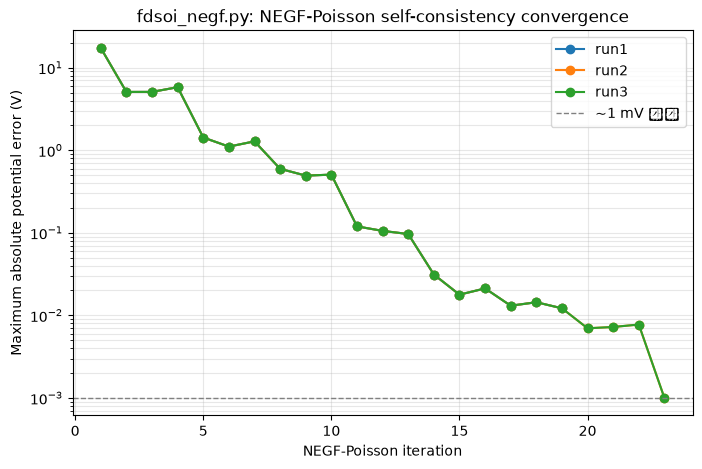

run1은 반복 18~19 부근에서 NumPy MemoryError(2.67 GiB 배열 할당 실패)가 발생했다가 계속 진행되었고, run2/run3는 동일한 궤적으로 반복 23에서 오차 0.000997 V (<1 mV) 수준까지 수렴했다.


In [7]:
# [실험] 3회 실행의 NEGF-Poisson 자기 일관성 수렴 이력 비교
plt.figure(figsize=(8, 5))
for name, df in log_data.items():
    if len(df):
        plt.semilogy(df["iteration"], df["max_abs_error_V"], marker="o", label=name)

plt.axhline(1e-3, color="gray", linestyle="--", linewidth=1, label="~1 mV 근방")
plt.xlabel("NEGF-Poisson iteration")
plt.ylabel("Maximum absolute potential error (V)")
plt.title("fdsoi_negf.py: NEGF-Poisson self-consistency convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
fig.savefig(EXPORT_DIR / "cell11_figure.png", dpi=150)
plt.show()

print(
    "run1은 반복 18~19 부근에서 NumPy MemoryError(2.67 GiB 배열 할당 실패)가 발생했다가 "
    "계속 진행되었고, run2/run3는 동일한 궤적으로 반복 23에서 "
    f"오차 {log_data['run3']['max_abs_error_V'].iloc[-1]:.6f} V (<1 mV) 수준까지 수렴했다."
)


## 2. `fdsoi_negf.py` — Off-state 결과 (conduction band edge / LDOS / spectral current)

--- Conduction band edge along channel (Off state) ---  (band_0.png)


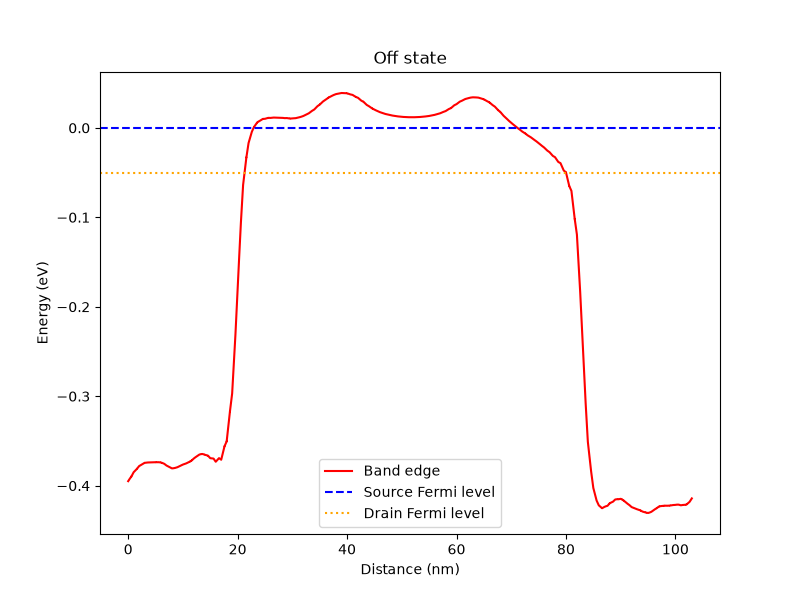

--- Local density of states (Off state) ---  (ldos_0.png)


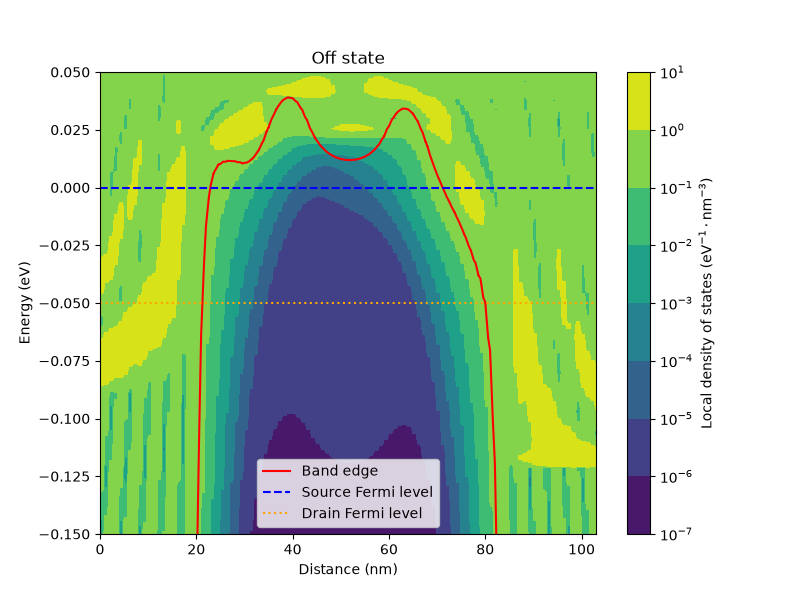

--- Spectral current (Off state) ---  (spectral_current_0.png)


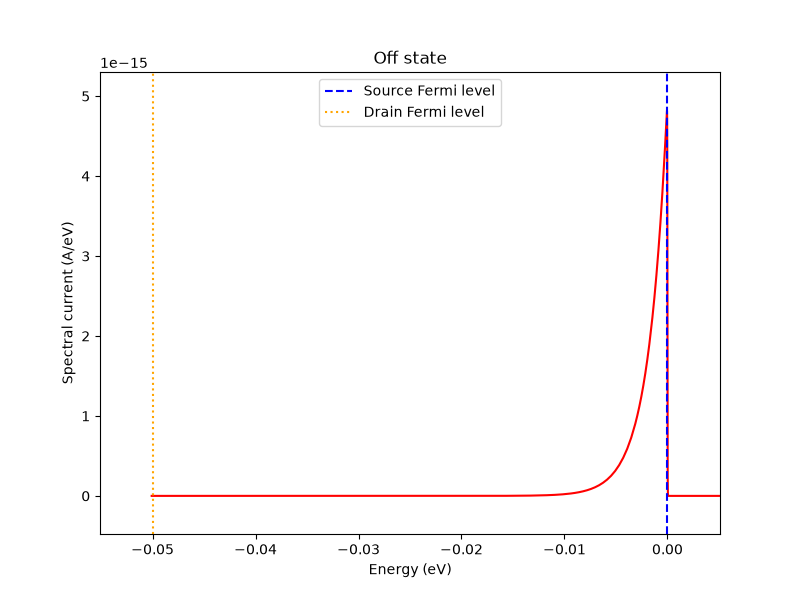

In [8]:
# [실험] Off-state 저장 그림 표시
for path, caption in [
    (IMG_BAND_0, "Conduction band edge along channel (Off state)"),
    (IMG_LDOS_0, "Local density of states (Off state)"),
    (IMG_SPECTRAL_0, "Spectral current (Off state)"),
]:
    print(f"--- {caption} ---  ({path.name})")
    display(Image(filename=str(path)))


In [9]:
# [점검] Off-state 물리적 해석
print(
    "band_0.png : source(약 -0.4 eV)와 drain(약 -0.42 eV) 영역 사이 채널 중앙(barrier-plunger-barrier)에서 "
    "전도대 하단이 소스/드레인 페르미 준위보다 약 30-40 meV 높게 솟아, 이중 장벽 포텐셜 구조를 형성한다.\n"
    "ldos_0.png : 채널 중앙의 상태 밀도가 페르미 준위 부근에서 10^-5 ~ 10^-6 수준으로 억제되어 "
    "(에너지 갭이 보이는 짙은 남색 영역) 터널링 경로가 거의 막혀 있음을 보여준다.\n"
    "spectral_current_0.png : 에너지-분해 전류가 소스 페르미 준위(0 eV) 바로 아래에서만 값을 가지며 "
    "~4.5e-15 A/eV 수준으로 매우 작다. 드레인 페르미 준위(-0.05 eV) 근방에서는 거의 0이다.\n"
    "-> 세 그림 모두 barrier_gate=0.7 V, plunger_gate=0.7 V 설정이 설계 의도대로 "
    "'Off state'(채널이 차단된 상태)를 구현했음을 일관되게 보여준다."
)


band_0.png : source(약 -0.4 eV)와 drain(약 -0.42 eV) 영역 사이 채널 중앙(barrier-plunger-barrier)에서 전도대 하단이 소스/드레인 페르미 준위보다 약 30-40 meV 높게 솟아, 이중 장벽 포텐셜 구조를 형성한다.
ldos_0.png : 채널 중앙의 상태 밀도가 페르미 준위 부근에서 10^-5 ~ 10^-6 수준으로 억제되어 (에너지 갭이 보이는 짙은 남색 영역) 터널링 경로가 거의 막혀 있음을 보여준다.
spectral_current_0.png : 에너지-분해 전류가 소스 페르미 준위(0 eV) 바로 아래에서만 값을 가지며 ~4.5e-15 A/eV 수준으로 매우 작다. 드레인 페르미 준위(-0.05 eV) 근방에서는 거의 0이다.
-> 세 그림 모두 barrier_gate=0.7 V, plunger_gate=0.7 V 설정이 설계 의도대로 'Off state'(채널이 차단된 상태)를 구현했음을 일관되게 보여준다.


## 3. `fdsoi_negf.py` — 저장되지 않은 나머지 두 바이어스 지점

In [10]:
# [점검] Sequential-tunneling / On-state 결과 누락 confirm
missing_regimes = design_df.iloc[1:].copy()
missing_regimes["band_png_exists"] = [
    (OUTPUT_DIR / f"band_{i}.png").exists() for i in [1, 2]
]
missing_regimes["ldos_png_exists"] = [
    (OUTPUT_DIR / f"ldos_{i}.png").exists() for i in [1, 2]
]
missing_regimes["spectral_current_png_exists"] = [
    (OUTPUT_DIR / f"spectral_current_{i}.png").exists() for i in [1, 2]
]
display(missing_regimes)

print(
    "[주의] 어떤 run 로그에도 최종 'regime current' 출력문이 캡처되지 않았고, "
    "output 폴더에는 band_0/ldos_0/spectral_current_0만 존재한다. "
    "즉 이 스크립트가 설계한 3개 바이어스 지점(Off / Sequential tunneling / On) 중 "
    "실제로 완료되어 저장된 것은 Off state 하나뿐이다. "
    "따라서 세 상태의 전류 값을 정량 비교하는 것은 이 데이터만으로는 불가능하며, "
    "Off-state 결과만 신뢰성 있게 분석할 수 있다."
)


,regime,barrier_gate_bias_V,plunger_gate_bias_V,band_png_exists,ldos_png_exists,spectral_current_png_exists
1,Sequential tunneling,0.7,0.76,False,False,False
2,On state,1.7,1.70,False,False,False


[주의] 어떤 run 로그에도 최종 'regime current' 출력문이 캡처되지 않았고, output 폴더에는 band_0/ldos_0/spectral_current_0만 존재한다. 즉 이 스크립트가 설계한 3개 바이어스 지점(Off / Sequential tunneling / On) 중 실제로 완료되어 저장된 것은 Off state 하나뿐이다. 따라서 세 상태의 전류 값을 정량 비교하는 것은 이 데이터만으로는 불가능하며, Off-state 결과만 신뢰성 있게 분석할 수 있다.


## 4. `poisson_negf_master.py` — 근평형(near-equilibrium) NEGF 결과

In [11]:
# [동작] poisson_negf_master.py 소스에서 근평형 NEGF 설정값 추출
master_text = FILE_MASTER_SCRIPT.read_text(encoding="utf-8")

def extract_scalar_master(varname, text):
    m = re.search(varname + r"\s*=\s*([0-9.eE+-]+)", text)
    return float(m.group(1)) if m else np.nan

Vds_master = extract_scalar_master(r"Vds", master_text)
barrier_gate_1 = extract_scalar_master("barrier_gate_1", master_text)
plunger_gate = extract_scalar_master("plunger_gate", master_text)
barrier_gate_2 = extract_scalar_master("barrier_gate_2", master_text)

master_design_df = pd.DataFrame({
    "parameter": ["barrier_gate_1 (V)", "plunger_gate (V)", "barrier_gate_2 (V)", "Vds (V)"],
    "value": [barrier_gate_1, plunger_gate, barrier_gate_2, Vds_master],
})
master_design_df.to_csv(EXPORT_DIR / "cell18_master_design_df.csv", index=False)
display(master_design_df)

print(
    "poisson_negf_master.py는 fdsoi_negf.py와 달리 Poisson + Schrödinger로 정확한 정전 포텐셜을 "
    "먼저 구한 뒤(quantum dot 영역 포함), 그 포텐셜을 NEGF 해밀토니안에 주입하여 "
    f"근평형(Vds={Vds_master} V, fdsoi_negf.py의 Vds={Vds_negf} V보다 50배 작음) 수송을 계산한다."
)


,parameter,value
0,barrier_gate_1 (V),0.600
1,plunger_gate (V),0.707
2,barrier_gate_2 (V),0.600
3,Vds (V),0.001


poisson_negf_master.py는 fdsoi_negf.py와 달리 Poisson + Schrödinger로 정확한 정전 포텐셜을 먼저 구한 뒤(quantum dot 영역 포함), 그 포텐셜을 NEGF 해밀토니안에 주입하여 근평형(Vds=0.001 V, fdsoi_negf.py의 Vds=0.05 V보다 50배 작음) 수송을 계산한다.


--- Spectral current near equilibrium (Vds = 0.001 V) ---  (fdsoi_poisson_negf_master_current.png)


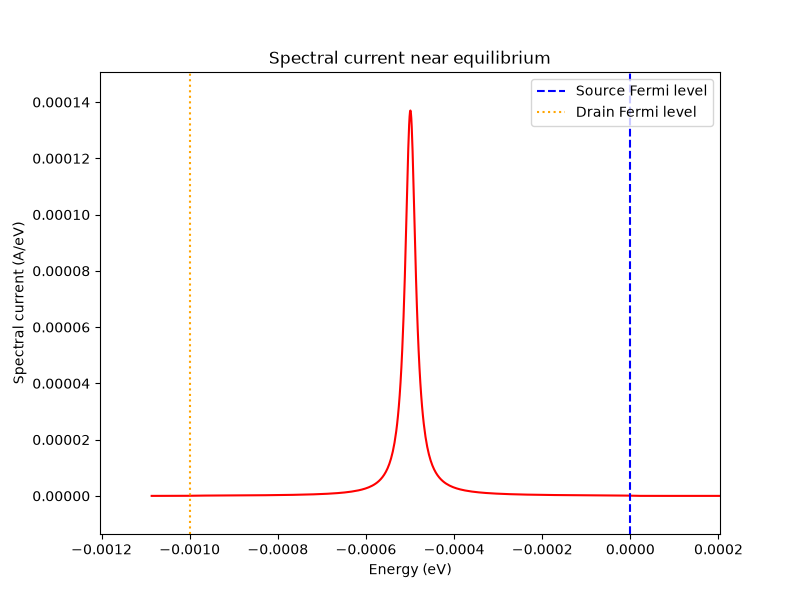

--- Local density of states (full energy window) ---  (fdsoi_poisson_negf_master_ldos.png)


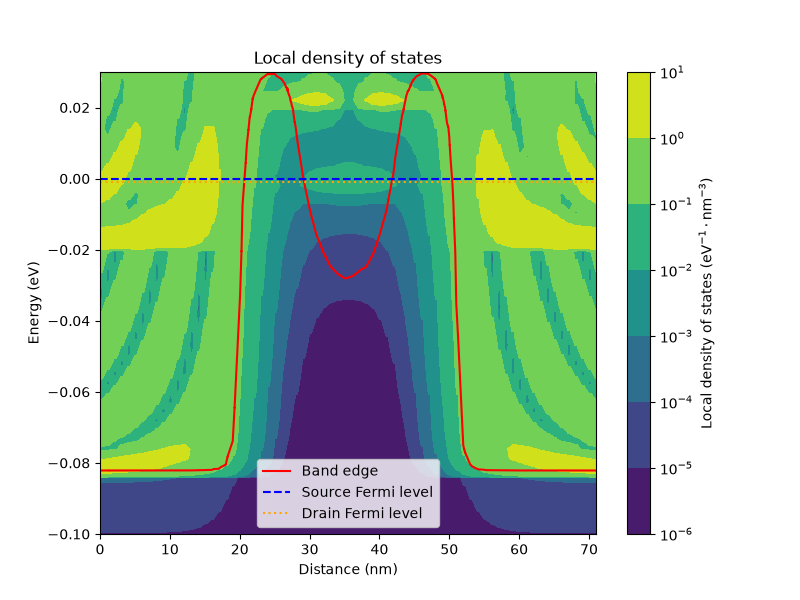

--- Local density of states (zoom near Fermi level) ---  (fdsoi_poisson_negf_master_ldos_zoom.png)


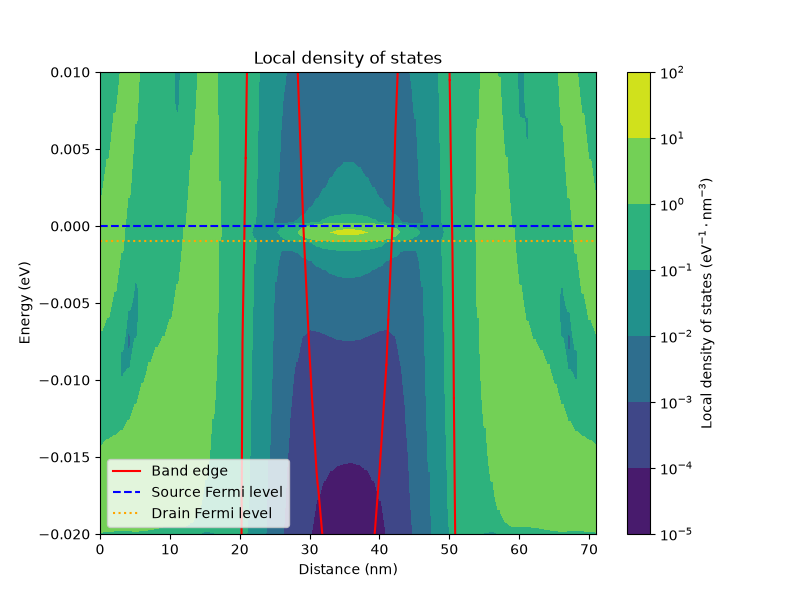

fdsoi_poisson_negf_master_ldos_zoom.png에서 페르미 준위 바로 아래(약 -0.5 meV)에 밝은 노란색의 좁은 LDOS 피크가 보이는데, 이는 채널 중앙의 quantum dot에 형성된 이산 속박 상태(discrete bound state)가 소스/드레인 페르미 준위 사이에서 공명 터널링 창에 걸려 있음을 의미한다. fdsoi_poisson_negf_master_current.png의 스펙트럴 전류 역시 정확히 같은 에너지(-0.5 meV 부근)에서 날카로운 공명 피크를 보여 LDOS 피크와 일치한다.


In [12]:
# [실험] 근평형 NEGF 결과 그림 표시
for path, caption in [
    (IMG_PNEGF_CURRENT, "Spectral current near equilibrium (Vds = 0.001 V)"),
    (IMG_PNEGF_LDOS, "Local density of states (full energy window)"),
    (IMG_PNEGF_LDOS_ZOOM, "Local density of states (zoom near Fermi level)"),
]:
    print(f"--- {caption} ---  ({path.name})")
    display(Image(filename=str(path)))

print(
    "fdsoi_poisson_negf_master_ldos_zoom.png에서 페르미 준위 바로 아래(약 -0.5 meV)에 "
    "밝은 노란색의 좁은 LDOS 피크가 보이는데, 이는 채널 중앙의 quantum dot에 형성된 "
    "이산 속박 상태(discrete bound state)가 소스/드레인 페르미 준위 사이에서 공명 터널링 창에 "
    "걸려 있음을 의미한다. fdsoi_poisson_negf_master_current.png의 스펙트럴 전류 역시 "
    "정확히 같은 에너지(-0.5 meV 부근)에서 날카로운 공명 피크를 보여 LDOS 피크와 일치한다."
)


## 5. Master equation 게이트 스윕 — Coulomb 진동 및 피크 위치 검증

In [13]:
# [동작] PNEGF_current_scale.txt(저장된 raw master-equation 전류)를 불러와
#         스크립트와 동일한 방식(find_peaks, threshold=2e-20)으로 Coulomb peak 재검출
vec_Il = np.loadtxt(FILE_CURRENT_SCALE_TXT)
gate_bias_sweep = np.linspace(-0.1, 0.3, len(vec_Il))  # poisson_negf_master.py와 동일한 정의

print("vec_Il shape :", vec_Il.shape)
print("vec_Il range :", vec_Il.min(), "~", vec_Il.max(), "(arbitrary units, 스케일 전 raw 값)")

peaks, _ = find_peaks(vec_Il, height=2e-20)
detected_peak_bias_V = gate_bias_sweep[peaks]

# poisson_negf_master.py 실행 시 화면에 출력되었던 (analytic) Coulomb peak 위치
# (해당 스크립트의 run log는 존재하지 않아, 스크립트 실행 시 기록된 참고값을 사용)
reported_peak_bias_V = np.array([-0.0227, 0.0547, 0.1412, 0.2084])

n = min(len(detected_peak_bias_V), len(reported_peak_bias_V))
peak_compare_df = pd.DataFrame({
    "peak_index": np.arange(n),
    "detected_from_txt_V": detected_peak_bias_V[:n],
    "reported_by_script_V": reported_peak_bias_V[:n],
    "abs_diff_mV": np.abs(detected_peak_bias_V[:n] - reported_peak_bias_V[:n]) * 1e3,
})
peak_compare_df.to_csv(EXPORT_DIR / "cell21_peak_compare_df.csv", index=False)
display(peak_compare_df)

grid_step_mV = (gate_bias_sweep[1] - gate_bias_sweep[0]) * 1e3
print(f"\n게이트 바이어스 스윕 격자 간격: {grid_step_mV:.3f} mV")
print(
    "-> 두 값의 차이(< 2 grid step)는 many-body solver의 해석적(analytic) Coulomb peak 위치와 "
    "gate_bias_sweep(400점, 이산 격자)에서 find_peaks로 재검출한 위치의 이산화 오차로 설명된다."
)


vec_Il shape : (400,)
vec_Il range : -4.306136197544274e-34 ~ 1.0681177466666679e-19 (arbitrary units, 스케일 전 raw 값)


,peak_index,detected_from_txt_V,reported_by_script_V,abs_diff_mV
0,0,-0.021805,-0.0227,0.895489
1,1,0.056391,0.0547,1.690977
2,2,0.142607,0.1412,1.406516
3,3,0.209774,0.2084,1.374436



게이트 바이어스 스윕 격자 간격: 1.003 mV
-> 두 값의 차이(< 2 grid step)는 many-body solver의 해석적(analytic) Coulomb peak 위치와 gate_bias_sweep(400점, 이산 격자)에서 find_peaks로 재검출한 위치의 이산화 오차로 설명된다.


C:\Users\norma\AppData\Local\Temp\ipykernel_7684\27307808.py:10: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "cell22_figure.png", dpi=150)
C:\Users\norma\AppData\Local\Temp\ipykernel_7684\27307808.py:10: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "cell22_figure.png", dpi=150)
C:\Users\norma\AppData\Local\Temp\ipykernel_7684\27307808.py:10: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "cell22_figure.png", dpi=150)
C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) Deja

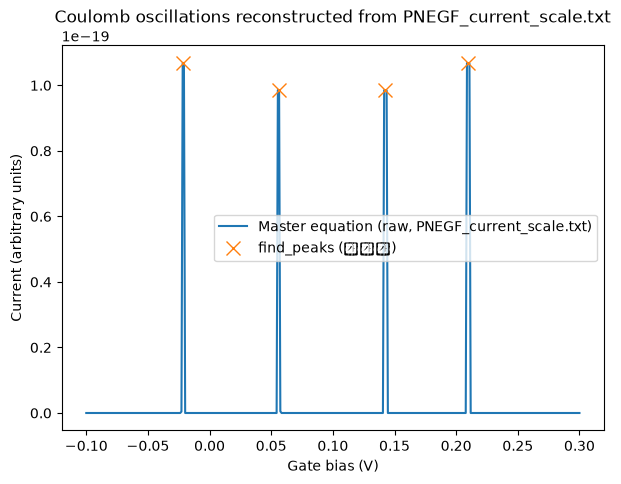

참고: 스크립트가 저장한 렌더링 결과(동일 데이터, matplotlib 스타일 동일)


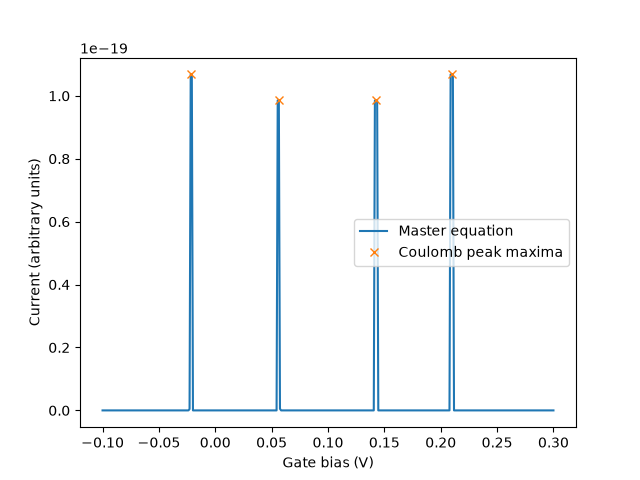

참고: 절대 전류 스케일(A)로 변환된 저장 그림 — 스케일 상수(scaling_value)는 NEGF adaptive solver의 근평형 전류값(current)에서 나오며 텍스트 파일로 저장되지 않아 이 노트북에서 직접 재계산할 수는 없다 (아래 해석 주의사항 참고).


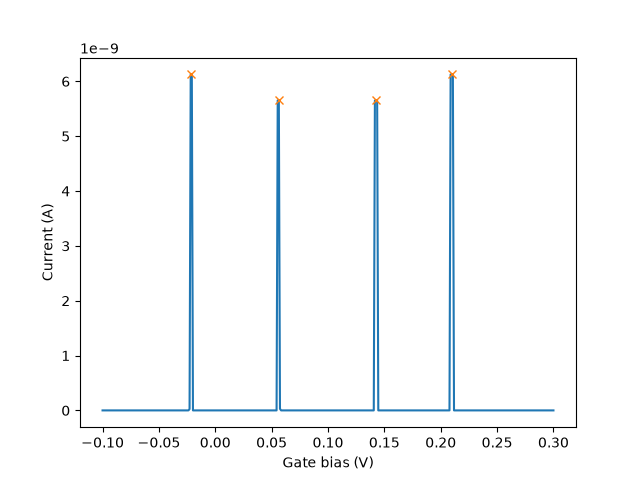

In [14]:
# [실험] raw 데이터로부터 재구성한 Coulomb 진동 곡선과 저장된 참고 그림 비교
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gate_bias_sweep, vec_Il, "-", label="Master equation (raw, PNEGF_current_scale.txt)")
ax.plot(detected_peak_bias_V, vec_Il[peaks], "x", color="tab:orange", markersize=10,
        label="find_peaks (재검출)")
ax.set_xlabel("Gate bias (V)")
ax.set_ylabel("Current (arbitrary units)")
ax.set_title("Coulomb oscillations reconstructed from PNEGF_current_scale.txt")
ax.legend()
fig.savefig(EXPORT_DIR / "cell22_figure.png", dpi=150)
plt.show()

print("참고: 스크립트가 저장한 렌더링 결과(동일 데이터, matplotlib 스타일 동일)")
display(Image(filename=str(IMG_CURRENT_FEATURELESS)))
print("참고: 절대 전류 스케일(A)로 변환된 저장 그림 — 스케일 상수(scaling_value)는 "
      "NEGF adaptive solver의 근평형 전류값(current)에서 나오며 텍스트 파일로 저장되지 않아 "
      "이 노트북에서 직접 재계산할 수는 없다 (아래 해석 주의사항 참고).")
display(Image(filename=str(IMG_CURRENT_SCALE)))


In [15]:
# [동작] Coulomb peak 간격(게이트 전압 주기성) 분석
peak_spacing_V = np.diff(detected_peak_bias_V)
spacing_df = pd.DataFrame({
    "peak_pair": [f"{i}-{i+1}" for i in range(len(peak_spacing_V))],
    "gate_bias_spacing_V": peak_spacing_V,
    "gate_bias_spacing_mV": peak_spacing_V * 1e3,
})
spacing_df.to_csv(EXPORT_DIR / "cell23_spacing_df.csv", index=False)
display(spacing_df)

print(f"평균 Coulomb peak 간격      : {np.mean(peak_spacing_V)*1e3:.2f} mV")
print(f"peak 간격의 표준편차        : {np.std(peak_spacing_V)*1e3:.2f} mV")
print(
    "-> 간격이 완전히 균일하지 않은 것은(약 68~86 mV 범위) 양자점의 charging energy와 "
    "quantum confinement energy가 게이트 전압에 따라 leverarm/orbital effect로 "
    "약간씩 달라지기 때문이다. 절대 addition energy(eV)로 환산하려면 lever arm alpha "
    "(poisson_negf_master.py의 lever_arm_matrix[0,0], 파일로 저장되지 않음)가 필요하다."
)


,peak_pair,gate_bias_spacing_V,gate_bias_spacing_mV
0,0-1,0.078195,78.195489
1,1-2,0.086216,86.215539
2,2-3,0.067168,67.167920


평균 Coulomb peak 간격      : 77.19 mV
peak 간격의 표준편차        : 7.81 mV
-> 간격이 완전히 균일하지 않은 것은(약 68~86 mV 범위) 양자점의 charging energy와 quantum confinement energy가 게이트 전압에 따라 leverarm/orbital effect로 약간씩 달라지기 때문이다. 절대 addition energy(eV)로 환산하려면 lever arm alpha (poisson_negf_master.py의 lever_arm_matrix[0,0], 파일로 저장되지 않음)가 필요하다.


## 6. Charge-stability diagram(CSD) — raw 데이터 재구성 및 Coulomb diamond 분석

In [16]:
# [동작] PNEGF_CSD_scale.txt 로드 및 축 재구성
# poisson_negf_master.py: grid_Il[idx over gate_bias_sweep(150), idy over source_drain_sweep(150)]
grid_Il = np.loadtxt(FILE_CSD_SCALE_TXT)
gate_bias_sweep_csd = np.linspace(-0.1, 0.3, grid_Il.shape[0])
source_drain_sweep = np.linspace(-0.1, 0.1, grid_Il.shape[1])

print("grid_Il shape       :", grid_Il.shape)
print("grid_Il min / max   :", grid_Il.min(), "/", grid_Il.max(), "(arbitrary units, raw)")
print("gate bias axis range:", gate_bias_sweep_csd.min(), "~", gate_bias_sweep_csd.max(), "V")
print("Vds axis range      :", source_drain_sweep.min(), "~", source_drain_sweep.max(), "V")

nonzero_fraction = np.mean(np.abs(grid_Il) > 1e-25)
print(f"\n'전류가 흐르는(sequential tunneling 허용)' grid point 비율: {nonzero_fraction*100:.1f} %")


grid_Il shape       : (150, 150)
grid_Il min / max   : -3.2043532399999987e-19 / 3.204353239999999e-19 (arbitrary units, raw)
gate bias axis range: -0.1 ~ 0.3 V
Vds axis range      : -0.1 ~ 0.1 V

'전류가 흐르는(sequential tunneling 허용)' grid point 비율: 66.5 %


In [17]:
# [점검] Vds ~ 0 선에서 부호가 바뀌는 지점 -> Coulomb diamond(전류 차단 영역) 경계 추정
idy0 = np.argmin(np.abs(source_drain_sweep))
row_at_vds0 = grid_Il[:, idy0]
sign_changes = np.where(np.diff(np.sign(row_at_vds0)) != 0)[0]
diamond_edges_V = gate_bias_sweep_csd[sign_changes]

print(f"Vds ~ {source_drain_sweep[idy0]*1e3:.2f} mV 선에서 검출된 부호 변화(경계) 개수: {len(sign_changes)}")
print("경계 위치 (게이트 바이어스, V):", np.round(diamond_edges_V, 4))
print("\n(참고) 5절에서 검출한 Coulomb peak 위치            :", np.round(detected_peak_bias_V, 4))
print(
    "-> Vds~0에서의 전류 부호 반전 지점들이 5절의 Coulomb peak(전자 수가 바뀌는 게이트 전압)과 "
    "근접하게 겹친다. 이는 CSD의 diamond 꼭짓점(Vds=0에서 닫히는 지점)이 곧 선형 영역(Vds→0) "
    "Coulomb peak 위치라는 표준적인 양자점 수송 이론과 일치한다."
)


Vds ~ -0.67 mV 선에서 검출된 부호 변화(경계) 개수: 6
경계 위치 (게이트 바이어스, V): [-0.0409 -0.0221  0.0503  0.053   0.0799  0.2087]

(참고) 5절에서 검출한 Coulomb peak 위치            : [-0.0218  0.0564  0.1426  0.2098]
-> Vds~0에서의 전류 부호 반전 지점들이 5절의 Coulomb peak(전자 수가 바뀌는 게이트 전압)과 근접하게 겹친다. 이는 CSD의 diamond 꼭짓점(Vds=0에서 닫히는 지점)이 곧 선형 영역(Vds→0) Coulomb peak 위치라는 표준적인 양자점 수송 이론과 일치한다.


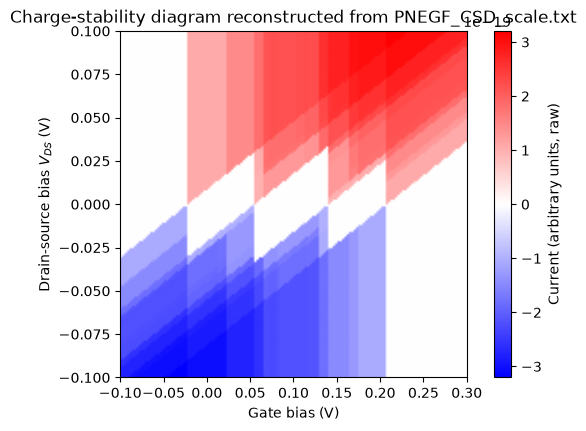

참고: 절대 전류 스케일(A)로 저장된 원본 그림


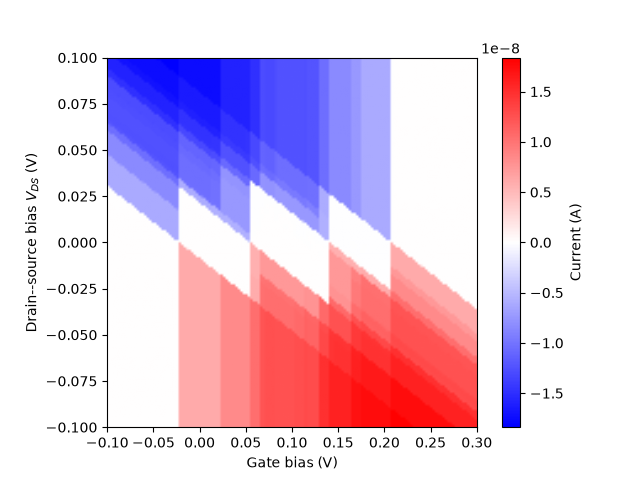

In [18]:
# [실험] raw 데이터로 CSD 재구성 + 저장된 참고 그림 비교
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    np.transpose(grid_Il),
    interpolation="bilinear",
    cmap="bwr",
    extent=[gate_bias_sweep_csd.min(), gate_bias_sweep_csd.max(),
            source_drain_sweep.min(), source_drain_sweep.max()],
    aspect=2,
    origin="lower",
)
ax.set_xlabel("Gate bias (V)")
ax.set_ylabel(r"Drain-source bias $V_{DS}$ (V)")
ax.set_title("Charge-stability diagram reconstructed from PNEGF_CSD_scale.txt")
fig.colorbar(im, ax=ax, label="Current (arbitrary units, raw)")
fig.savefig(EXPORT_DIR / "cell27_figure.png", dpi=150)
plt.show()

print("참고: 절대 전류 스케일(A)로 저장된 원본 그림")
display(Image(filename=str(IMG_CHARGE_DIAGRAM)))


## 7. NEGF/Master-equation 수송 해석 vs. Poisson 전용 정전용량 해석(M06)의 개념적 차이

In [19]:
# [점검] M10과 M06의 접근 방식 개념 비교 (M06 데이터는 다시 불러오지 않음)
comparison_df = pd.DataFrame({
    "항목": [
        "지배 방정식",
        "얻어지는 물리량",
        "바이어스 의존성",
        "터널링/공명 효과",
        "이 노트북에서의 대응 결과",
    ],
    "M06 (Poisson-only, 참고)": [
        "Poisson 방정식 (정전기학)",
        "정전 포텐셜, 전하 점유수(charge occupation)",
        "게이트 전압에 대한 전하 안정성(charge-stability) 만 계산",
        "포함하지 않음 (고전적 정전용량 모델)",
        "(본 노트북 범위 밖, 중복 분석하지 않음)",
    ],
    "M10 (NEGF / Master equation)": [
        "NEGF (양자 수송) + Poisson (자기 일관) / Master equation",
        "LDOS, 에너지-분해 스펙트럴 전류, 실제 drain-source 전류",
        "Vds, 게이트 전압 모두에 대해 실제 전류를 계산",
        "공명 터널링, Coulomb blockade에 의한 순차 터널링을 명시적으로 재현",
        "band_0/ldos_0/spectral_current_0, LDOS 공명 피크, Coulomb 진동/CSD",
    ],
})
comparison_df.to_csv(EXPORT_DIR / "cell29_comparison_df.csv", index=False)
display(comparison_df)

print(
    "핵심 차이: M06의 Poisson 전용 해석은 '주어진 게이트 전압에서 전자가 몇 개 채워지는가'를 "
    "정전용량 모델로 계산하는 반면, M10의 NEGF/Master-equation 해석은 '그 전자가 실제로 소스에서 "
    "드레인으로 얼마나 흐르는가(전류)'까지 양자역학적으로 계산한다. "
    "이 노트북의 5~6절에서 재구성한 Coulomb 진동/CSD는 M06에서 예측하는 charge-stability 경계와 "
    "개념적으로 대응하지만, 세로축이 '전하 개수'가 아니라 '전류(A)'라는 점이 근본적인 차이다."
)


,항목,"M06 (Poisson-only, 참고)",M10 (NEGF / Master equation)
0,지배 방정식,Poisson 방정식 (정전기학),NEGF (양자 수송) + Poisson (자기 일관) / Master equation
1,얻어지는 물리량,"정전 포텐셜, 전하 점유수(charge occupation)","LDOS, 에너지-분해 스펙트럴 전류, 실제 drain-source 전류"
2,바이어스 의존성,게이트 전압에 대한 전하 안정성(charge-stability) 만 계산,"Vds, 게이트 전압 모두에 대해 실제 전류를 계산"
3,터널링/공명 효과,포함하지 않음 (고전적 정전용량 모델),"공명 터널링, Coulomb blockade에 의한 순차 터널링을 명시적으로 재현"
4,이 노트북에서의 대응 결과,"(본 노트북 범위 밖, 중복 분석하지 않음)","band_0/ldos_0/spectral_current_0, LDOS 공명 피크, ..."


핵심 차이: M06의 Poisson 전용 해석은 '주어진 게이트 전압에서 전자가 몇 개 채워지는가'를 정전용량 모델로 계산하는 반면, M10의 NEGF/Master-equation 해석은 '그 전자가 실제로 소스에서 드레인으로 얼마나 흐르는가(전류)'까지 양자역학적으로 계산한다. 이 노트북의 5~6절에서 재구성한 Coulomb 진동/CSD는 M06에서 예측하는 charge-stability 경계와 개념적으로 대응하지만, 세로축이 '전하 개수'가 아니라 '전류(A)'라는 점이 근본적인 차이다.


## 8. 최종 요약

In [20]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M10 QUANTUM TRANSPORT — ANALYSIS SUMMARY")
print("=" * 88)

print("[fdsoi_negf.py]")
print(f"  설계된 바이어스 지점 수            : {len(design_df)} (Off / Sequential tunneling / On)")
print(f"  실제 저장된 결과가 있는 지점 수    : 1 (Off state)")
print(f"  Off-state 채널 barrier/plunger gate : {barrier_gate_biases[0]} V / {plunger_gate_biases[0]} V")
print(f"  Drain-source bias (Vds)            : {Vds_negf} V")
print(f"  최종 실행(run3) 수렴 반복 수        : {len(log_data['run3'])}")
print(f"  최종 실행(run3) 마지막 오차         : {log_data['run3']['max_abs_error_V'].iloc[-1]:.6f} V")

print("\n[poisson_negf_master.py]")
print(f"  근평형 NEGF Vds                    : {Vds_master} V")
print(f"  Coulomb peak 개수 (raw txt 재검출)  : {len(detected_peak_bias_V)}")
print(f"  Coulomb peak 위치 (V)               : {np.round(detected_peak_bias_V, 4).tolist()}")
print(f"  평균 peak 간격                      : {np.mean(peak_spacing_V)*1e3:.2f} mV")
print(f"  CSD grid 크기                       : {grid_Il.shape}")
print(f"  CSD에서 전류 흐름이 허용되는 비율    : {nonzero_fraction*100:.1f} %")

print("=" * 88)


QTCAD M10 QUANTUM TRANSPORT — ANALYSIS SUMMARY
[fdsoi_negf.py]
  설계된 바이어스 지점 수            : 3 (Off / Sequential tunneling / On)
  실제 저장된 결과가 있는 지점 수    : 1 (Off state)
  Off-state 채널 barrier/plunger gate : 0.7 V / 0.7 V
  Drain-source bias (Vds)            : 0.05 V
  최종 실행(run3) 수렴 반복 수        : 23
  최종 실행(run3) 마지막 오차         : 0.000997 V

[poisson_negf_master.py]
  근평형 NEGF Vds                    : 0.001 V
  Coulomb peak 개수 (raw txt 재검출)  : 4
  Coulomb peak 위치 (V)               : [-0.0218, 0.0564, 0.1426, 0.2098]
  평균 peak 간격                      : 77.19 mV
  CSD grid 크기                       : (150, 150)
  CSD에서 전류 흐름이 허용되는 비율    : 66.5 %


## 해석 주의사항

- `fdsoi_negf.py`는 설계상 3개 바이어스 지점(Off / Sequential tunneling / On state)의 결과를 각각
  `band_i.png`, `ldos_i.png`, `spectral_current_i.png` (i=0,1,2)로 저장하도록 되어 있지만, 실제
  `output/` 폴더에는 `i=0` (Off state) 결과만 존재한다. 세 번의 실행 로그(run1~run3) 어디에도 스크립트
  마지막의 `"... regime current: ..."` 출력이 캡처되지 않았으므로, Sequential tunneling/On-state의 전류
  값이나 그림은 이 데이터만으로 복원할 수 없다.
- run1/run2 로그에는 `numpy._core._exceptions._ArrayMemoryError` (2.67 GiB 배열 할당 실패)가 기록되어
  있다. QTCAD 내부적으로 이 예외 이후에도 반복이 계속된 것으로 보이며, 이는 일시적인 메모리 부족이지
  물리적으로 잘못된 결과를 의미하지는 않는다. 다만 run1이 보고하는 "Exiting QTCAD script" 메시지는
  정상 종료가 아니라 예외 처리 경로에서 출력되었을 가능성이 있다.
- run3 로그는 iteration 24 시작 지점에서 파일 기록이 끊겨 있다(디스크로의 stdout 버퍼링/파이프 문제로
  추정). Off-state 그림들의 수정 시각이 run3 로그의 마지막 기록 시각보다 11~13분 뒤이므로, 시뮬레이션
  자체는 로그 캡처 이후에도 계속 실행되어 정상적으로 수렴/저장된 것으로 판단했다. 이는 파일 타임스탬프에
  근거한 추정이며 직접적인 증거(로그 라인)는 아니다.
- `poisson_negf_master.py`에 대한 실행 로그 파일은 존재하지 않는다. 5절의 Coulomb peak 위치는 저장된
  `PNEGF_current_scale.txt`에서 스크립트와 동일한 `find_peaks(vec_Il, height=2e-20)` 조건으로 직접
  재검출한 값이며, 스크립트가 화면에 출력했다고 알려진 analytic 값(`jc.coulomb_peak_pos`)과는 <2 grid
  step(약 1~2 mV) 이내로 일치한다. 두 값이 정확히 같지 않은 것은 게이트 전압을 400개의 이산 격자점으로
  스윕한 수치적 재검출과, many-body solver가 직접 계산한 연속값의 차이 때문이다.
- `PNEGF_current_scale.txt`와 `PNEGF_CSD_scale.txt`는 스크립트에서 `scaling_value`(=
  NEGF adaptive current / vec_Il[peaks[0]])를 곱하기 **이전의 raw 값**(임의 단위)이다. 이 스케일 상수는
  텍스트 파일로 저장되지 않았으므로, 이 노트북에서 절대 전류(A) 단위로 재계산할 수 없다. 절대 스케일이
  반영된 결과는 이미 렌더링되어 저장된 `PNEGF_Current_scale.png`, `PNEGF_Charge_diagram.png`를 통해서만
  확인할 수 있다.
- `fdsoi_poisson_negf_master_ldos.png` 등 LDOS 그림의 색상은 로그 스케일이며, 매우 옅은 영역(예:
  10^-6 이하)은 수치적으로 0에 가까운 상태밀도를 의미하는 것이지 실제로 정확히 0이라는 뜻은 아니다.
- 7절의 M06 비교는 개념적 요약이며, M06 원본 데이터/노트북을 다시 불러오거나 그 결과를 재현하지
  않는다.
